Analizar el mercado laboral representado en las ofertas de Glassdoor para identificar los perfiles profesionales con mayor demanda, los niveles salariales asociados y las características de las empresas que están contratando.

| Pregunta                                 | Qué queremos medir           | Posible valor                         |
| ---------------------------------------- | ---------------------------- | ------------------------------------- |
| ¿Cuáles son las ofertas más recurrentes? | Frecuencia de cargos/puestos | Identificar áreas con mayor presencia |
| ¿Cuál es el salario promedio?            | Tendencia salarial           | Comparar remuneración entre perfiles  |
| ¿Qué perfiles son más requeridos?        | Demanda por profesión/rol    | Detectar oportunidades laborales      |


In [ ]:
#cargar data set
ruta = 

In [2]:
# Librerías para manipular datos y para graficar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# 🎨 Paleta de colores del curso — la usamos igual en las dos sesiones
# para que todo el material se sienta parte de una misma historia visual.
COLOR_PRIMARIO  = "#2a78d6"  # azul  -> el dato principal de cada gráfica
COLOR_ACENTO    = "#eb6834"  # naranja -> lo que queremos resaltar (un hallazgo, un candidato)
COLOR_AQUA      = "#1baf7a"  # verde azulado -> una segunda categoría cuando hace falta
COLOR_SIN       = "#c9c8c2"  # gris -> "sin" algo, contraste neutro
COLOR_TEXTO     = "#0b0b0b"
COLOR_TEXTO_SEC = "#52514e"
COLOR_EJE       = "#898781"
COLOR_GRID      = "#e1e0d9"
COLOR_SUPERFICIE = "#fcfcfb"

mpl.rcParams.update({
    "figure.facecolor": COLOR_SUPERFICIE,
    "axes.facecolor": COLOR_SUPERFICIE,
    "axes.edgecolor": COLOR_EJE,
    "axes.labelcolor": COLOR_TEXTO_SEC,
    "text.color": COLOR_TEXTO,
    "xtick.color": COLOR_EJE,
    "ytick.color": COLOR_EJE,
    "grid.color": COLOR_GRID,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
})

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 120)


# Visualización y analisis inicial del df

In [3]:
df= pd.read_csv(ruta)
df.head()

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,hourly,employer_provided,min_salary,max_salary,avg_salary,company_txt,job_state,same_state,age,python_yn,R_yn,spark,aws,excel,job_simp,seniority,desc_len,num_comp
0,0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,Company - Private,Aerospace & Defense,Aerospace & Defense,$50 to $100 million (USD),-1,0,0,53,91,72.0,Tecolote Research,NM,0,47,1,0,0,0,1,data scientist,na,2536,0
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,Other Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,0,0,63,112,87.5,University of Maryland Medical System,MD,0,36,1,0,0,0,0,data scientist,na,4783,0
2,2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,Company - Private,Security Services,Business Services,$100 to $500 million (USD),-1,0,0,80,90,85.0,KnowBe4,FL,1,10,1,0,1,0,1,data scientist,na,3461,0
3,3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,Government,Energy,"Oil, Gas, Energy & Utilities",$500 million to $1 billion (USD),"Oak Ridge National Laboratory, National Renewa...",0,0,56,97,76.5,PNNL,WA,1,55,1,0,0,0,0,data scientist,na,3883,3
4,4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee",0,0,86,143,114.5,Affinity Solutions,NY,1,22,1,0,0,0,1,data scientist,na,2728,3


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 742 entries, 0 to 741
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         742 non-null    int64  
 1   Job Title          742 non-null    object 
 2   Salary Estimate    742 non-null    object 
 3   Job Description    742 non-null    object 
 4   Rating             742 non-null    float64
 5   Company Name       742 non-null    object 
 6   Location           742 non-null    object 
 7   Headquarters       742 non-null    object 
 8   Size               742 non-null    object 
 9   Founded            742 non-null    int64  
 10  Type of ownership  742 non-null    object 
 11  Industry           742 non-null    object 
 12  Sector             742 non-null    object 
 13  Revenue            742 non-null    object 
 14  Competitors        742 non-null    object 
 15  hourly             742 non-null    int64  
 16  employer_provided  742 non

In [5]:
df.shape


(742, 33)

In [6]:
df.columns

Index(['Unnamed: 0', 'Job Title', 'Salary Estimate', 'Job Description', 'Rating', 'Company Name', 'Location',
       'Headquarters', 'Size', 'Founded', 'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'hourly', 'employer_provided', 'min_salary', 'max_salary', 'avg_salary', 'company_txt', 'job_state',
       'same_state', 'age', 'python_yn', 'R_yn', 'spark', 'aws', 'excel', 'job_simp', 'seniority', 'desc_len',
       'num_comp'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 742 entries, 0 to 741
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         742 non-null    int64  
 1   Job Title          742 non-null    object 
 2   Salary Estimate    742 non-null    object 
 3   Job Description    742 non-null    object 
 4   Rating             742 non-null    float64
 5   Company Name       742 non-null    object 
 6   Location           742 non-null    object 
 7   Headquarters       742 non-null    object 
 8   Size               742 non-null    object 
 9   Founded            742 non-null    int64  
 10  Type of ownership  742 non-null    object 
 11  Industry           742 non-null    object 
 12  Sector             742 non-null    object 
 13  Revenue            742 non-null    object 
 14  Competitors        742 non-null    object 
 15  hourly             742 non-null    int64  
 16  employer_provided  742 non

In [8]:
df.describe()

,Unnamed: 0,Rating,Founded,hourly,employer_provided,min_salary,max_salary,avg_salary,same_state,age,python_yn,R_yn,spark,aws,excel,desc_len,num_comp
count,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000
mean,370.500000,3.618868,1837.154987,0.032345,0.022911,74.719677,128.149596,100.626011,0.557951,46.591644,0.528302,0.002695,0.225067,0.237197,0.522911,3869.545822,1.053908
std,214.341239,0.801210,497.183763,0.177034,0.149721,30.980593,45.220324,38.855948,0.496965,53.778815,0.499535,0.051882,0.417908,0.425651,0.499812,1521.495868,1.384239
min,0.000000,-1.000000,-1.000000,0.000000,0.000000,15.000000,16.000000,13.500000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,407.000000,0.000000
25%,185.250000,3.300000,1939.000000,0.000000,0.000000,52.000000,96.000000,73.500000,0.000000,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2801.000000,0.000000
50%,370.500000,3.700000,1988.000000,0.000000,0.000000,69.500000,124.000000,97.500000,1.000000,24.000000,1.000000,0.000000,0.000000,0.000000,1.000000,3731.000000,0.000000
75%,555.750000,4.000000,2007.000000,0.000000,0.000000,91.000000,155.000000,122.500000,1.000000,59.000000,1.000000,0.000000,0.000000,0.000000,1.000000,4740.000000,3.000000
max,741.000000,5.000000,2019.000000,1.000000,1.000000,202.000000,306.000000,254.000000,1.000000,276.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10051.000000,4.000000


In [9]:
df.isna().sum()

Unnamed: 0           0
Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         0
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
hourly               0
employer_provided    0
min_salary           0
max_salary           0
avg_salary           0
company_txt          0
job_state            0
same_state           0
age                  0
python_yn            0
R_yn                 0
spark                0
aws                  0
excel                0
job_simp             0
seniority            0
desc_len             0
num_comp             0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.nunique()

Unnamed: 0           742
Job Title            264
Salary Estimate      416
Job Description      463
Rating                31
Company Name         343
Location             200
Headquarters         198
Size                   9
Founded              102
Type of ownership     11
Industry              60
Sector                25
Revenue               14
Competitors          128
hourly                 2
employer_provided      2
min_salary           114
max_salary           160
avg_salary           225
company_txt          343
job_state             37
same_state             2
age                  102
python_yn              2
R_yn                   2
spark                  2
aws                    2
excel                  2
job_simp               7
seniority              3
desc_len             443
num_comp               5
dtype: int64

# Análisis de variables, qué se queda y qué se va

Determinar qué variables tienen valor analítico y cuáles son redundantes, auxiliares o prescindibles.
| Categoría             | Significado                                          |
| --------------------- | ---------------------------------------------------- |
| 🟢 **Clave**          | Responde directamente una pregunta de negocio        |
| 🔵 **Complementaria** | Permite profundizar o encontrar relaciones           |
| 🟡 **Derivada**       | Ya fue calculada a partir de otras columnas          |
| 🟠 **Redundante**     | Contiene información que ya tenemos en otra variable |
| 🔴 **Prescindible**   | No aporta al análisis que estamos planteando         |



In [12]:
df[["Job Title","job_simp","Company Name"]].nunique()

Job Title       264
job_simp          7
Company Name    343
dtype: int64

### Nivel 1 — Perfil profesional
job_simp ¿Qué grandes perfiles profesionales tienen mayor presencia?
### Nivel 2 — Cargo específico
Job Title Para profundizar. Dentro de data engineer, ¿qué títulos específicos aparecen?

En lugar de simplemente: ¿Qué perfiles son los más requeridos?
Podríamos plantearla como: ¿Qué perfiles profesionales presentan mayor demanda dentro de las ofertas analizadas 
y qué cargos específicos conforman esos perfiles?

#### Job Title = demasiado granular
#### job_simp = posiblemente demasiado general
#### Nuestra nueva clasificación = punto intermedio

enriquecimiento / transformación de datos: na representa 24,7% del dataset. Es demasiado para tratarlo simplemente como ruido.
Ya tenemos una fuente de información que probablemente nos permita recuperar parte de esa clasificación: Job Title

Grupo Data Scientist
Buscar títulos relacionados con:
Data Scientist
Data Science
etc.

Grupo Data Engineer Buscar:
Data Engineer
Data Engineering

Grupo Analyst Buscar:
Data Analyst
Business Analyst
Analytics

Grupo Machine Learning Buscar:
Machine Learning
ML Engineer
MLE

Grupo Manager Buscar:
Manager
Director

"Otros" debe existir, pero como último recurso.

| Categoría propuesta | Qué incluiría                                                          |
| ------------------- | ---------------------------------------------------------------------- |
| `data scientist`    | Data Scientist y títulos claramente equivalentes                       |
| `data engineer`     | Data Engineer y variantes                                              |
| `analyst`           | Data Analyst, Business Analyst, etc.                                   |
| `mle`               | Machine Learning Engineer y equivalentes                               |
| `manager`           | Managers relacionados con estas áreas                                  |
| `other scientist`   | Research Scientist, Medical Laboratory Scientist, Food Scientist, etc. |
| `other data`        | Data Professional, Data Modeler, Data Science Engineer, etc.           |
| `other`             | Casos que no podamos clasificar razonablemente                         |


In [13]:
df["job_simp"].value_counts()

job_simp
data scientist    279
na                184
data engineer     119
analyst           102
manager            22
mle                22
director           14
Name: count, dtype: int64

In [14]:
df["job_simp"].value_counts(normalize=True)

job_simp
data scientist    0.376011
na                0.247978
data engineer     0.160377
analyst           0.137466
manager           0.029650
mle               0.029650
director          0.018868
Name: proportion, dtype: float64

In [15]:
# Filtrar el DataFrame y mostrar los Job Title correspondientes
# pd.set_option('display.max_rows', None)
df[df['job_simp'] == 'na']['Job Title'].value_counts()


Job Title
Research Scientist                                                                                    4
Medical Laboratory Scientist                                                                          4
R&D Specialist/ Food Scientist                                                                        4
MED TECH/LAB SCIENTIST- SOUTH COASTAL LAB                                                             4
Food Scientist - Developer                                                                            4
                                                                                                     ..
RESEARCH SCIENTIST - BIOLOGICAL SAFETY                                                                1
Associate Scientist/Scientist, Process Analytical Technology - Small Molecule Analytical Chemistry    1
Staff Scientist                                                                                       1
CONSULTANT– DATA ANALYTICS GROUP                      

In [16]:
# Filtro combinado con ambas condiciones
filtro = (df["job_simp"] == "na") & (df["Job Title"].str.contains("scientist", case=False, na=False))
len(df[filtro])

143

In [17]:
filtro = (df["job_simp"] == "na") & (df["Job Title"].str.contains("data", case=False, na=False))
len(df[filtro])

36

In [18]:
# Filtro: job_simp es 'na' Y Job Title NO contiene ni 'scientist' ni 'data'
filtro = (df["job_simp"] == "na") & ~(df["Job Title"].str.contains("scientist|data", case=False, na=False))
df[filtro][["Job Title", "job_simp"]]


,Job Title,job_simp
70,Analytics Consultant,na
333,Consultant - Analytics Consulting,na
387,Salesforce Analytics Consultant,na
479,Consultant - Analytics Consulting,na
588,Salesforce Analytics Consultant,na
652,Consultant - Analytics Consulting,na


In [19]:
#Validar si alguna oferta cabe en las dos categorias
filtro_ambos = (df["job_simp"] == "na") & df["Job Title"].str.contains("scientist", case=False, na=False) & (df["Job Title"].str.contains("data", case=False, na=False))
df[filtro_ambos][["Job Title", "job_simp"]]

,Job Title,job_simp
69,R&D Data Analysis Scientist,na


## Recategorizar na en job_simp

In [20]:

# 1. Definir las condiciones lógicas
condiciones = [
    (df['job_simp'] == 'na') & df['Job Title'].str.contains('scientist', case=False, na=False),
    (df['job_simp'] == 'na') & df['Job Title'].str.contains('data', case=False, na=False),
    (df['job_simp'] == 'na') # Si es 'na' y no cumplió las anteriores, por descarte no tiene 'data' ni 'scientist'
]

# 2. Definir los valores asignados a cada condición
resultados = [
    'other scientist',
    'other data',
    'Consultant'
]

# 3. Aplicar np.select actualizando la columna
df['job_simp'] = np.select(condiciones, resultados, default=df['job_simp'])
df["job_simp"].value_counts(normalize=True)

job_simp
data scientist     0.376011
other scientist    0.192722
data engineer      0.160377
analyst            0.137466
other data         0.047170
manager            0.029650
mle                0.029650
director           0.018868
Consultant         0.008086
Name: proportion, dtype: float64

In [21]:
df["job_simp"].value_counts()

job_simp
data scientist     279
other scientist    143
data engineer      119
analyst            102
other data          35
manager             22
mle                 22
director            14
Consultant           6
Name: count, dtype: int64

## Análisando hourly ¿Cómo está construido?

In [22]:
df[["hourly","employer_provided"]].value_counts()

hourly  employer_provided
0       0                    704
1       0                     21
0       1                     14
1       1                      3
Name: count, dtype: int64

In [23]:
filtro = (df["hourly"]==1)
df[filtro][["Salary Estimate","min_salary","max_salary","avg_salary","hourly","employer_provided"]].head(10)

,Salary Estimate,min_salary,max_salary,avg_salary,hourly,employer_provided
165,$17-$24 Per Hour(Glassdoor est.),34,48,20.5,1,0
177,$21-$34 Per Hour(Glassdoor est.),42,68,27.5,1,0
197,$18-$25 Per Hour(Glassdoor est.),36,50,21.5,1,0
202,$21-$34 Per Hour(Glassdoor est.),42,68,27.5,1,0
210,$15-$25 Per Hour(Glassdoor est.),30,50,20.0,1,0
246,$17-$24 Per Hour(Glassdoor est.),34,48,20.5,1,0
271,$21-$34 Per Hour(Glassdoor est.),42,68,27.5,1,0
337,$18-$25 Per Hour(Glassdoor est.),36,50,21.5,1,0
345,$24-$39 Per Hour(Glassdoor est.),48,78,31.5,1,0
357,$21-$34 Per Hour(Glassdoor est.),42,68,27.5,1,0


In [24]:
filtro = (df["hourly"]==0)
df[filtro][["Salary Estimate","min_salary","max_salary","avg_salary","hourly","employer_provided"]].head(10)

,Salary Estimate,min_salary,max_salary,avg_salary,hourly,employer_provided
0,$53K-$91K (Glassdoor est.),53,91,72.0,0,0
1,$63K-$112K (Glassdoor est.),63,112,87.5,0,0
2,$80K-$90K (Glassdoor est.),80,90,85.0,0,0
3,$56K-$97K (Glassdoor est.),56,97,76.5,0,0
4,$86K-$143K (Glassdoor est.),86,143,114.5,0,0
5,$71K-$119K (Glassdoor est.),71,119,95.0,0,0
6,$54K-$93K (Glassdoor est.),54,93,73.5,0,0
7,$86K-$142K (Glassdoor est.),86,142,114.0,0,0
8,$38K-$84K (Glassdoor est.),38,84,61.0,0,0
9,$120K-$160K (Glassdoor est.),120,160,140.0,0,0


## Análisando hourly ¿Qué valores tiene?

In [25]:
df["seniority"].value_counts()

seniority
na        520
senior    220
jr          2
Name: count, dtype: int64

## Industry vs Sector ¿Cúal nos conviene más?

In [26]:
df["Industry"].value_counts()

Industry
Biotech & Pharmaceuticals                   112
Insurance Carriers                           63
Computer Hardware & Software                 59
IT Services                                  50
Health Care Services & Hospitals             49
Enterprise Software & Network Solutions      42
Internet                                     29
Consulting                                   29
Aerospace & Defense                          25
Advertising & Marketing                      25
Consumer Products Manufacturing              20
Research & Development                       19
Colleges & Universities                      16
Energy                                       14
Banks & Credit Unions                        12
Federal Agencies                             11
-1                                           10
Staffing & Outsourcing                       10
Travel Agencies                               8
Lending                                       8
Food & Beverage Manufacturing  

In [27]:
df["Sector"].value_counts()

Sector
Information Technology                180
Biotech & Pharmaceuticals             112
Business Services                      97
Insurance                              69
Health Care                            49
Finance                                42
Manufacturing                          34
Aerospace & Defense                    25
Education                              23
Retail                                 15
Oil, Gas, Energy & Utilities           14
Government                             11
-1                                     10
Non-Profit                              9
Transportation & Logistics              8
Real Estate                             8
Travel & Tourism                        8
Telecommunications                      6
Media                                   6
Arts, Entertainment & Recreation        4
Consumer Services                       4
Mining & Metals                         3
Construction, Repair & Maintenance      3
Agriculture & Forestry     

## Company Name vs company_txt

In [28]:
df["Company Name"].nunique()


343

In [29]:
df["company_txt"].nunique()

343

In [30]:
df[["Company Name", "company_txt"]].head(10)

,Company Name,company_txt
0,Tecolote Research\n3.8,Tecolote Research
1,University of Maryland Medical System\n3.4,University of Maryland Medical System
2,KnowBe4\n4.8,KnowBe4
3,PNNL\n3.8,PNNL
4,Affinity Solutions\n2.9,Affinity Solutions
5,CyrusOne\n3.4,CyrusOne
6,ClearOne Advantage\n4.1,ClearOne Advantage
7,Logic20/20\n3.8,Logic20/20
8,Rochester Regional Health\n3.3,Rochester Regional Health
9,<intent>\n4.6,<intent>


## Location vs job_state

In [31]:
df["Location"].nunique()

200

In [32]:
df["job_state"].nunique()

37

In [33]:
df[["Location", "job_state"]].head(10)

,Location,job_state
0,"Albuquerque, NM",NM
1,"Linthicum, MD",MD
2,"Clearwater, FL",FL
3,"Richland, WA",WA
4,"New York, NY",NY
5,"Dallas, TX",TX
6,"Baltimore, MD",MD
7,"San Jose, CA",CA
8,"Rochester, NY",NY
9,"New York, NY",NY


## Finalmente las últimas variables

In [34]:
# Revenue, Type of ownership, Competitors, Founded, age, same_state, num_comp y desc_len
df["Revenue"].value_counts()


Revenue
Unknown / Non-Applicable            203
$10+ billion (USD)                  124
$100 to $500 million (USD)           91
$1 to $2 billion (USD)               60
$500 million to $1 billion (USD)     57
$50 to $100 million (USD)            46
$25 to $50 million (USD)             40
$2 to $5 billion (USD)               39
$10 to $25 million (USD)             32
$5 to $10 billion (USD)              19
$5 to $10 million (USD)              18
$1 to $5 million (USD)                8
Less than $1 million (USD)            4
-1                                    1
Name: count, dtype: int64

In [35]:
df["Type of ownership"].value_counts()

Type of ownership
Company - Private                 410
Company - Public                  193
Nonprofit Organization             55
Subsidiary or Business Segment     34
Government                         15
Hospital                           15
College / University               13
Other Organization                  3
School / School District            2
Unknown                             1
-1                                  1
Name: count, dtype: int64

In [36]:
df["Competitors"].value_counts()

Competitors
-1                                                                                              460
Novartis, Baxter, Pfizer                                                                         14
Oak Ridge National Laboratory, National Renewable Energy Lab, Los Alamos National Laboratory     12
Travelers, Allstate, State Farm                                                                  10
Roche, GlaxoSmithKline, Novartis                                                                  9
                                                                                               ... 
BrowserStack, Selenium Master, Perfecto Mobile                                                    1
Boeing, Northrop Grumman, Raytheon                                                                1
Unilever, Procter & Gamble, Henkel                                                                1
TASC, Vencore, Booz Allen Hamilton                                                      

In [37]:
df["Founded"].value_counts()

Founded
-1       50
 2010    32
 2008    31
 1996    27
 2006    24
         ..
 1860     1
 1942     1
 1878     1
 1971     1
 1889     1
Name: count, Length: 102, dtype: int64

In [38]:
df["age"].value_counts()

age
-1      50
 10     32
 12     31
 24     27
 14     24
        ..
 160     1
 78      1
 142     1
 49      1
 131     1
Name: count, Length: 102, dtype: int64

In [39]:
df["same_state"].value_counts()

same_state
1    414
0    328
Name: count, dtype: int64

In [40]:
df["num_comp"].value_counts()

num_comp
0    460
3    228
2     41
1     12
4      1
Name: count, dtype: int64

In [41]:
df["desc_len"].value_counts()

desc_len
3670    5
3243    4
3846    4
4608    4
4637    4
       ..
1884    1
5435    1
2505    1
2774    1
3813    1
Name: count, Length: 443, dtype: int64

In [42]:
df[["num_comp","Competitors"]]

,num_comp,Competitors
0,0,-1
1,0,-1
2,0,-1
3,3,"Oak Ridge National Laboratory, National Renewa..."
4,3,"Commerce Signals, Cardlytics, Yodlee"
...,...,...
737,3,"Pfizer, AstraZeneca, Merck"
738,3,"See Tickets, TicketWeb, Vendini"
739,0,-1
740,0,-1


## Después de todo este proceso, tenemos:

🟢 Variables principales

-Perfil
job_simp

-Salario
avg_salary
hourly

-Empresa
company_txt
Rating
Size
Sector

-Ubicación
job_state

-Skills
python_yn
R_yn
spark
aws
excel

🟡 Variables secundarias

Revenue
Type of ownership
age
same_state
Industry
Location
seniority

🔴 Variables descartadas
Unnamed
Company Name
Founded
Competitors
num_comp
desc_len
Job Description

# EDA 
1-¿Cuáles son las ofertas laborales más recurrentes?
2-¿Cuál es el salario estimado?
3-¿Qué perfiles son los más requeridos?

## ¿Cuáles son las ofertas laborales más recurrentes? 

In [43]:
# Porcentajes conjuntos: scientist + data engineer


frecuencias = df["job_simp"].value_counts(normalize=True)

# Filtrar por los índices nos interesan usando .loc y los suma
total = frecuencias.loc[["data scientist", "data engineer"]].sum()
print(total)


0.5363881401617251


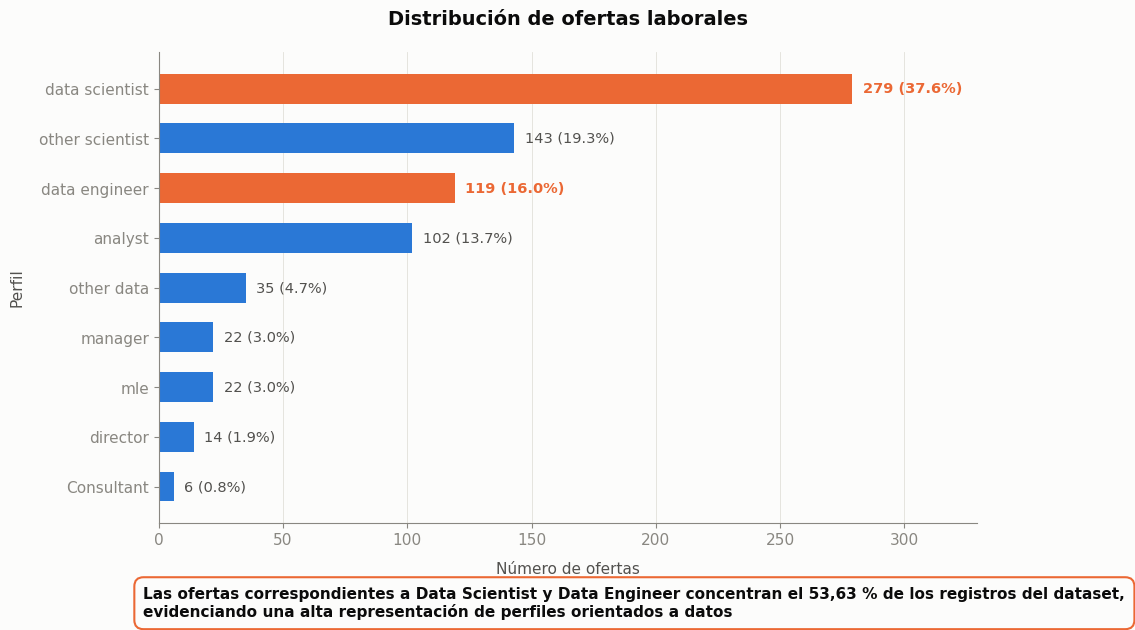

In [44]:


# 1. Obtener conteos y porcentajes (frecuencias)
conteo_puestos = df["job_simp"].value_counts()
frecuencias = df["job_simp"].value_counts(normalize=True)

# 2. Invertir el orden para que las barras más largas queden arriba
conteo_puestos = conteo_puestos.iloc[::-1]

# 3. Asignar colores condicionales según tu paleta
# Resaltamos con COLOR_ACENTO el hallazgo del Insight; el resto usa COLOR_PRIMARIO
colores = [
    COLOR_ACENTO if perfil in ["data scientist", "data engineer"] else COLOR_PRIMARIO
    for perfil in conteo_puestos.index
]

# 4. Crear el gráfico de barras horizontales
plt.figure(figsize=(10, 6))
barras = plt.barh(conteo_puestos.index, conteo_puestos.values, color=colores, height=0.6)

# 5. Agregar las etiquetas dinámicas "Conteo (Porcentaje%)"
for i, (perfil, conteo) in enumerate(conteo_puestos.items()):
    porcentaje = frecuencias[perfil] * 100
    texto_etiqueta = f"{conteo} ({porcentaje:.1f}%)"
    
    # Si la barra es del Insight, ponemos el texto en negrita con COLOR_ACENTO
    es_hallazgo = perfil in ["data scientist", "data engineer"]
    color_texto_barra = COLOR_ACENTO if es_hallazgo else COLOR_TEXTO_SEC
    peso_fuente = "bold" if es_hallazgo else "normal"
    
    # Colocar el texto con un ligero margen a la derecha de la barra
    plt.text(conteo + (conteo_puestos.max() * 0.015), i, texto_etiqueta, 
             va='center', ha='left', fontsize=10.5, color=color_texto_barra, weight=peso_fuente)

# 6. Personalizar títulos y ejes con la identidad gráfica
plt.title("Distribución de ofertas laborales", fontsize=14, fontweight='bold', pad=20, color=COLOR_TEXTO)
plt.xlabel("Número de ofertas", fontsize=11, labelpad=10)
plt.ylabel("Perfil", fontsize=11, labelpad=10)

# Ajustar el límite horizontal para que no se corten las etiquetas de texto
plt.xlim(0, conteo_puestos.max() * 1.18)

# Activar solo la cuadrícula vertical para no saturar las barras horizontales
plt.gca().grid(axis='y', linestyle='none') # Oculta líneas horizontales de la cuadrícula
plt.gca().grid(axis='x', linestyle='-', linewidth=0.6, color=COLOR_GRID)

# 7. Agregar el recuadro de Insight estilizado abajo
# Usamos un borde sutil con COLOR_ACENTO y fondo limpio para mantener la estética del curso
insight_texto = (
                 "Las ofertas correspondientes a Data Scientist y Data Engineer concentran el 53,63 % de los registros del dataset,\n"
                  "evidenciando una alta representación de perfiles orientados a datos"
)
plt.figtext(0.15, -0.04, insight_texto, fontsize=11, fontweight='bold', color=COLOR_TEXTO,
            bbox=dict(facecolor=COLOR_SUPERFICIE, edgecolor=COLOR_ACENTO, linewidth=1.5, boxstyle='round,pad=0.6'))

# 8. Ajustar diseño y mostrar
plt.tight_layout()
plt.show();




### Las ofertas relacionadas con Data Scientist y Data Engineer concentran más de la mitad de los registros del dataset, evidenciando una alta presencia de perfiles orientados a datos.

## ¿Cuál es el salario estimado?

In [45]:
# Crea una tabla de frecuencias cruzadas
tabla_crosstab = pd.crosstab(df["job_simp"], df["hourly"])
print(tabla_crosstab)


hourly             0   1
job_simp                
Consultant         6   0
analyst          100   2
data engineer    119   0
data scientist   279   0
director          14   0
manager           22   0
mle               22   0
other data        35   0
other scientist  121  22


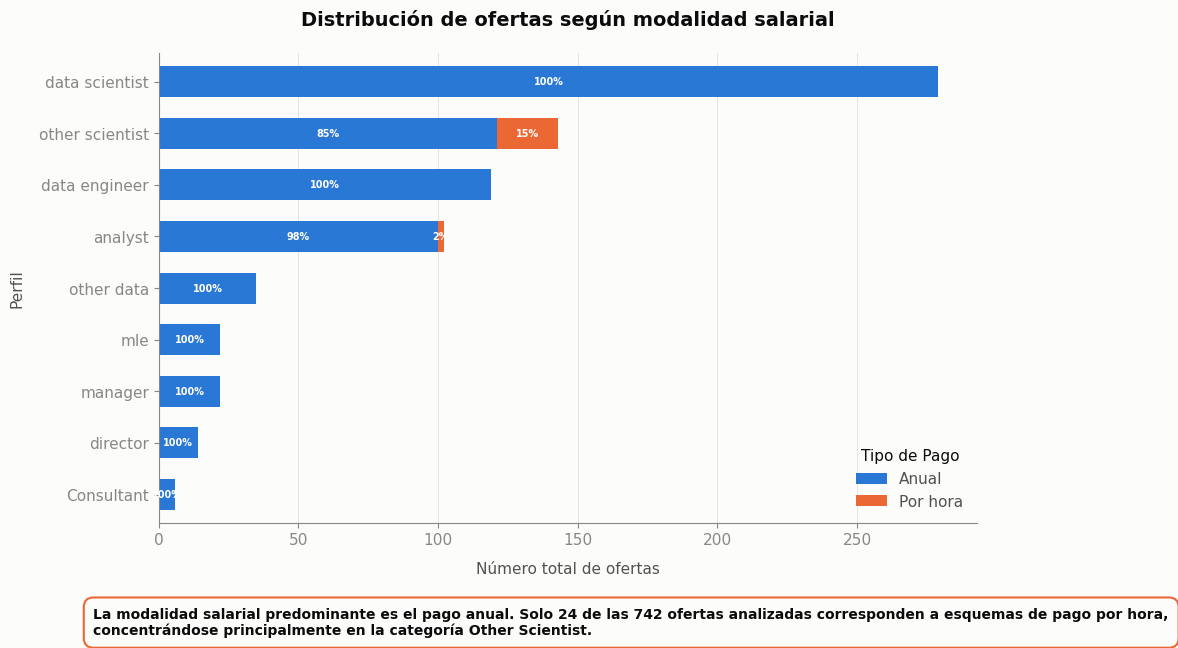

In [46]:

# 1. Crear la tabla cruzada
tabla_crosstab = pd.crosstab(df["job_simp"], df["hourly"])

# Renombramos las columnas del resultado para que la leyenda del gráfico sea legible
tabla_crosstab.columns = ["Anual", "Por hora"]

# 2. Ordenar las categorías de forma descendente por el total de ofertas
# Esto garantiza que el perfil con más mercado aparezca arriba
tabla_crosstab["Total"] = tabla_crosstab["Anual"] + tabla_crosstab["Por hora"]
tabla_crosstab = tabla_crosstab.sort_values(by="Total", ascending=True) # Ascending=True porque barh dibuja de abajo hacia arriba
tabla_crosstab = tabla_crosstab.drop(columns=["Total"])

# 3. Crear el gráfico de barras horizontales apiladas (stacked=True)
# Asignamos el azul al formato Anual y el naranja (acento) a Por hora
fig, ax = plt.subplots(figsize=(10, 6))
tabla_crosstab.plot(
    kind="barh", 
    stacked=True, 
    ax=ax, 
    color=[COLOR_PRIMARIO, COLOR_ACENTO], 
    width=0.6
)

# Calcular los totales por fila para poder obtener el porcentaje exacto de cada segmento
totales_por_perfil = tabla_crosstab.sum(axis=1).values

# Iterar sobre cada tipo de pago (Anual y Por hora) para colocar sus respectivas etiquetas
for c in ax.containers:
    # Generamos las etiquetas calculando el porcentaje respecto al total de su perfil
    etiquetas = [
        f"{(valor / total) * 100:.0f}%" if valor > 0 else "" 
        for valor, total in zip(c.datavalues, totales_por_perfil)
    ]
    
    # Añadir los textos centrados dentro de cada segmento de la barra apilada
    ax.bar_label(
        c, 
        labels=etiquetas, 
        label_type='center', 
        color='white',       # Contraste ideal sobre el azul y naranja
        fontweight='bold', 
        fontsize=7
    )

# 4. Personalizar títulos, etiquetas y leyenda
plt.title("Distribución de ofertas según modalidad salarial", fontsize=14, fontweight="bold", pad=20, color=COLOR_TEXTO)
plt.xlabel("Número total de ofertas", fontsize=11, labelpad=10)
plt.ylabel("Perfil", fontsize=11, labelpad=10)

# Ajustar la leyenda usando la tipografía y colores secundarios del curso
plt.legend(title="Tipo de Pago", frameon=False, loc="lower right", labelcolor=COLOR_TEXTO_SEC)

# 5. Configurar la cuadrícula (solo líneas verticales de fondo)
ax.grid(axis='y', linestyle='none')
ax.grid(axis='x', linestyle='-', linewidth=0.6, color=COLOR_GRID)

# Usamos saltos de línea (\n) para que el texto se distribuya estéticamente dentro del cuadro
insight_texto = (
    "La modalidad salarial predominante es el pago anual. Solo 24 de las 742 ofertas analizadas corresponden a esquemas de pago por hora,\n"
    "concentrándose principalmente en la categoría Other Scientist."
)

plt.figtext(
    0.10, -0.07, insight_texto, 
    fontsize=10, 
    fontweight='bold', 
    color=COLOR_TEXTO,
    bbox=dict(
        facecolor=COLOR_SUPERFICIE, 
        edgecolor=COLOR_ACENTO, 
        linewidth=1.5, 
        boxstyle='round,pad=0.7'
    )
)

# 6. Mostrar el gráfico
plt.tight_layout()
plt.show();


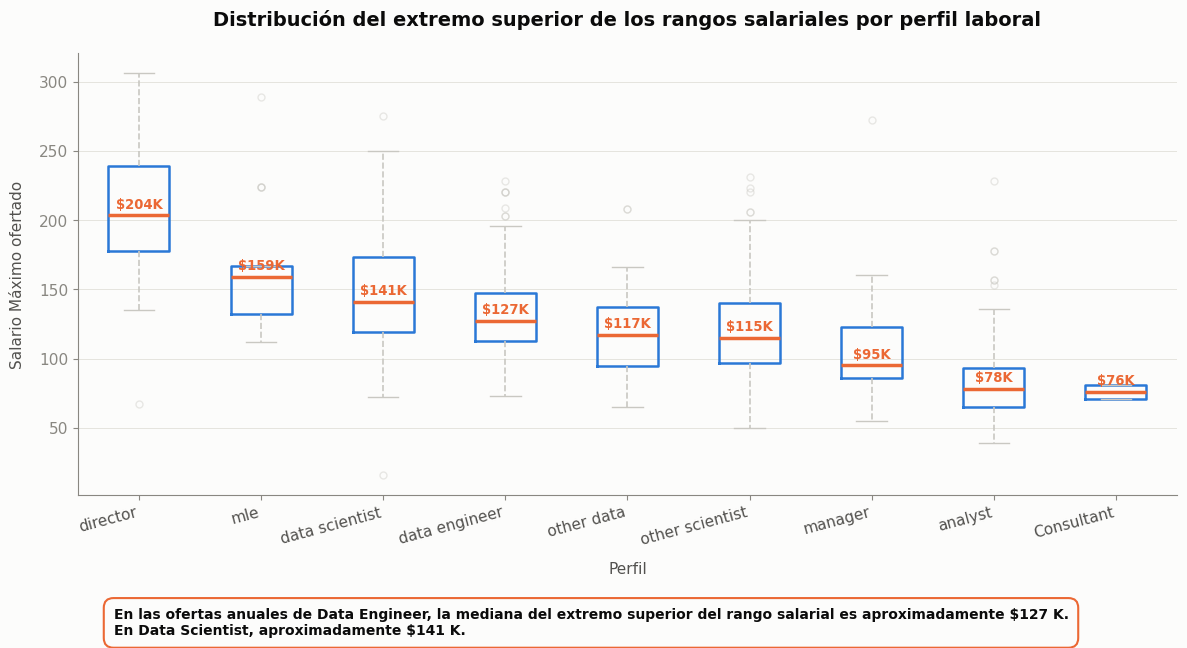

In [47]:
# 1. Filtrar únicamente las ofertas anuales (hourly == 0)
df_anual = df[df["hourly"] == 0].dropna(subset=["job_simp", "max_salary"])

# 2. Obtener las categorías de perfiles ordenadas por su salario máximo mediano
# Esto hace que el gráfico sea mucho más fácil de leer que un orden aleatorio
categorias_ordenadas = df_anual.groupby("job_simp")["max_salary"].median().sort_values(ascending=False).index

# 3. Preparar los datos agrupados para Matplotlib
datos_por_perfil = [df_anual[df_anual["job_simp"] == perfil]["max_salary"] for perfil in categorias_ordenadas]

# 4. Crear la figura
plt.figure(figsize=(12, 6))

# 5. Diseñar los estilos con la paleta del curso
propiedades_caja = dict(color=COLOR_PRIMARIO, linewidth=1.8)
propiedades_mediana = dict(color=COLOR_ACENTO, linewidth=2.5)
propiedades_bigotes = dict(color=COLOR_SIN, linewidth=1.2, linestyle="--")


# 6. Personalizar títulos, etiquetas y diseño de ejes
plt.title("Distribución del extremo superior de los rangos salariales por perfil laboral", fontsize=14, fontweight="bold", pad=20, color=COLOR_TEXTO)
plt.xlabel("Perfil", fontsize=11, labelpad=10)
plt.ylabel("Salario Máximo ofertado", fontsize=11, labelpad=10)

# Rotar las etiquetas del eje X si son muy largas para evitar que se encimen
plt.xticks(rotation=15, ha="right", color=COLOR_TEXTO_SEC)

# Ajustar cuadrícula (líneas horizontales de fondo ayudan a leer los salarios en el eje Y)
plt.gca().grid(axis='x', linestyle='none')
plt.gca().grid(axis='y', linestyle='-', linewidth=0.6, color=COLOR_GRID)

# 1. Captura el diccionario guardando el boxplot en una variable (agrega "bp = ")
bp = plt.boxplot(
    datos_por_perfil,
    tick_labels=categorias_ordenadas,
    vert=True,
    patch_artist=False,
    boxprops=propiedades_caja,
    medianprops=propiedades_mediana,
    whiskerprops=propiedades_bigotes,
    capprops=dict(color=COLOR_SIN),
    flierprops=dict(markeredgecolor=COLOR_SIN, marker='o', alpha=0.4, markersize=5)
)

# 2. Iterar sobre las medianas y dibujar las etiquetas
for median in bp['medians']:
    # Extraer las coordenadas X e Y de la línea de la mediana
    x_coords, y_coords = median.get_data()
    
    # El centro horizontal de la caja está en el promedio de sus coordenadas X
    x_pos = sum(x_coords) / 2
    # El valor del salario es la coordenada Y (ambos puntos de la línea tienen el mismo Y)
    y_pos = y_coords[0]
    
    # Formatear el texto (ej: si es 120000 lo muestra como 120.0K, ajusta según datos)
    texto_mediana = f"{y_pos/1000:.1f}K" if y_pos >= 1000 else f"${y_pos:.0f}K"
    
    # Dibujar la etiqueta ligeramente por encima de la línea de la mediana
    plt.text(
        x_pos, 
        y_pos + (df_anual["max_salary"].max() * 0.01),  # Pequeño margen hacia arriba
        texto_mediana,
        ha='center', 
        va='bottom', 
        fontsize=9.5, 
        fontweight='bold',
        color=COLOR_ACENTO  # Mismo color naranja de la línea para mantener la armonía
    )

    insight_texto = (
    "En las ofertas anuales de Data Engineer, la mediana del extremo superior del rango salarial es aproximadamente $127 K.\n"
        "En Data Scientist, aproximadamente $141 K."
)

plt.figtext(
    0.10, -0.07, insight_texto, 
    fontsize=10, 
    fontweight='bold', 
    color=COLOR_TEXTO,
    bbox=dict(
        facecolor=COLOR_SUPERFICIE, 
        edgecolor=COLOR_ACENTO, 
        linewidth=1.5, 
        boxstyle='round,pad=0.7'
    )
)

# 7. Ajustar diseño y mostrar
plt.tight_layout()
plt.show();

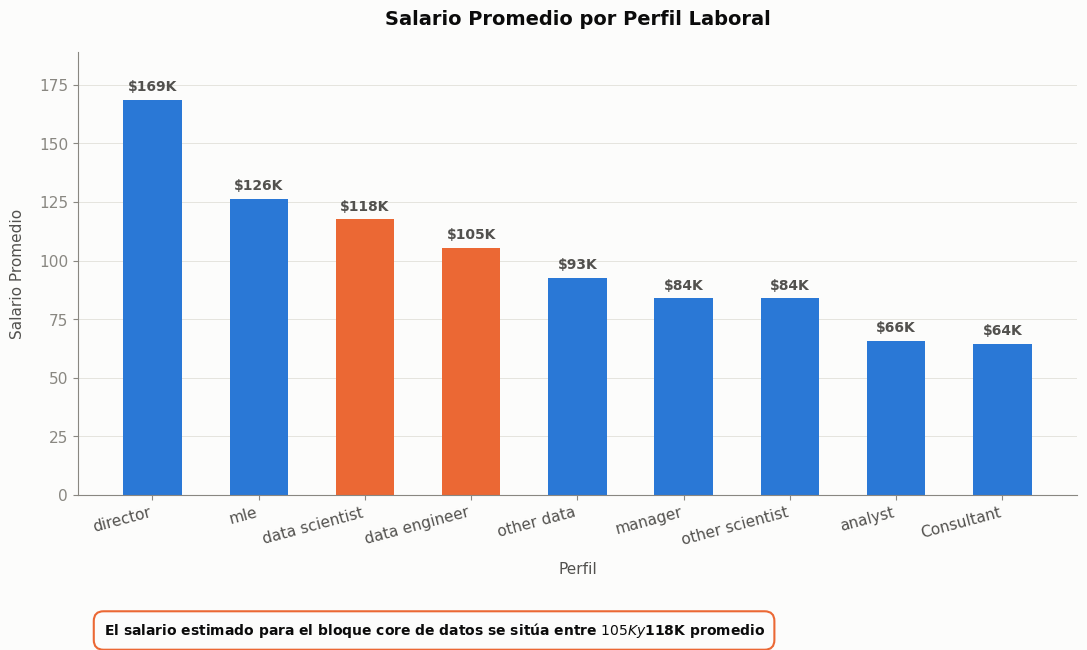

In [48]:


# 1. Calcular el salario promedio por perfil laboral
# Agrupamos por perfil, calculamos la media y ordenamos de mayor a menor
salario_promedio_perfil = (
    df.groupby("job_simp")["avg_salary"]
    .mean()
    .sort_values(ascending=False)
)

# 2. Crear la figura para el gráfico de columnas
plt.figure(figsize=(11, 6))

colores_barras = [
    COLOR_ACENTO if perfil in ["data scientist", "data engineer"] else COLOR_PRIMARIO
    for perfil in salario_promedio_perfil.index
]

# 3. Dibujar las columnas (barras verticales) usando el color principal del curso
columnas = plt.bar(
    salario_promedio_perfil.index, 
    salario_promedio_perfil.values, 
    color=colores_barras, 
    width=0.55
)

# 4. Agregar etiquetas de texto con el valor exacto sobre cada columna
for columna in columnas:
    y_val = columna.get_height()  # Obtiene el valor del salario promedio
    x_pos = columna.get_x() + columna.get_width() / 2  # Centrado horizontal
    
    # Formatear el salario a formato miles (K) para evitar saturación visual
    texto_salario = f"${y_val/1000:.1f}K" if y_val >= 1000 else f"${y_val:.0f}K"

    
    # Colocar el texto justo arriba de la columna
    plt.text(
        x_pos, 
        y_val + (salario_promedio_perfil.max() * 0.015),  # Margen superior del 1.5%
        texto_salario, 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        fontweight='bold', 
        color=COLOR_TEXTO_SEC
    )

# 5. Personalizar títulos, etiquetas y diseño de ejes
plt.title("Salario Promedio por Perfil Laboral", fontsize=14, fontweight='bold', pad=20, color=COLOR_TEXTO)
plt.xlabel("Perfil", fontsize=11, labelpad=10)
plt.ylabel("Salario Promedio", fontsize=11, labelpad=10)

# Rotar los nombres de los perfiles para que no se encimen
plt.xticks(rotation=15, ha="right", color=COLOR_TEXTO_SEC)

# Expandir el límite superior del eje Y para dar espacio a las etiquetas de texto
plt.ylim(0, salario_promedio_perfil.max() * 1.12)

# Configurar cuadrícula horizontal sutil de fondo
plt.gca().grid(axis='x', linestyle='none')
plt.gca().grid(axis='y', linestyle='-', linewidth=0.6, color=COLOR_GRID)

# Usamos saltos de línea (\n) para que el texto se distribuya estéticamente dentro del cuadro
insight_texto = (
    "El salario estimado para el bloque core de datos se sitúa entre $105K y $118K promedio"
)

plt.figtext(
    0.10, -0.07, insight_texto, 
    fontsize=10, 
    fontweight='bold', 
    color=COLOR_TEXTO,
    bbox=dict(
        facecolor=COLOR_SUPERFICIE, 
        edgecolor=COLOR_ACENTO, 
        linewidth=1.5, 
        boxstyle='round,pad=0.7'
    )
)

# 6. Ajustar diseño y mostrar
plt.tight_layout()
plt.show();


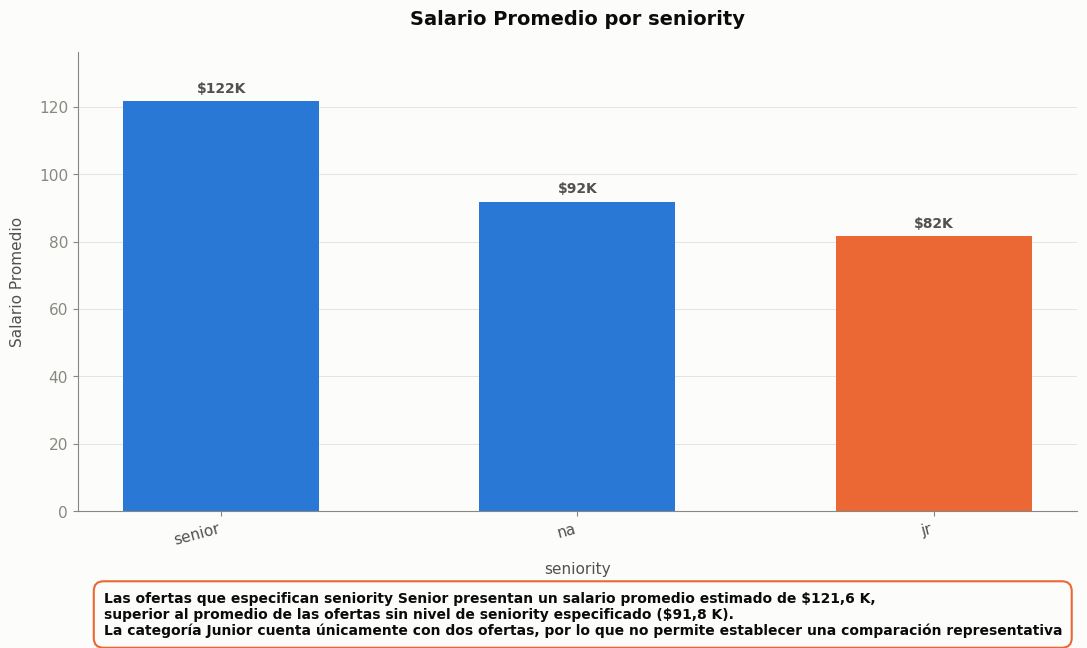

In [49]:



salario_promedio_seniority = (
    df.groupby("seniority")["avg_salary"]
    .mean()
    .sort_values(ascending=False)
)

# 2. Crear la figura para el gráfico de columnas
plt.figure(figsize=(11, 6))


# 3. Dibujar las columnas (barras verticales) usando el color principal del curso
columnas = plt.bar(
    salario_promedio_seniority.index, 
    salario_promedio_seniority.values, 
    color=colores_barras, 
    width=0.55
)

# 4. Agregar etiquetas de texto con el valor exacto sobre cada columna
for columna in columnas:
    y_val = columna.get_height()  # Obtiene el valor del salario promedio
    x_pos = columna.get_x() + columna.get_width() / 2  # Centrado horizontal
    
    # Formatear el salario a formato miles (K) para evitar saturación visual
    texto_salario = f"${y_val/1000:.1f}K" if y_val >= 1000 else f"${y_val:.0f}K"

    
    # Colocar el texto justo arriba de la columna
    plt.text(
        x_pos, 
        y_val + (salario_promedio_seniority.max() * 0.015),  # Margen superior del 1.5%
        texto_salario, 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        fontweight='bold', 
        color=COLOR_TEXTO_SEC
    )

# 5. Personalizar títulos, etiquetas y diseño de ejes
plt.title("Salario Promedio por seniority", fontsize=14, fontweight='bold', pad=20, color=COLOR_TEXTO)
plt.xlabel("seniority", fontsize=11, labelpad=10)
plt.ylabel("Salario Promedio", fontsize=11, labelpad=10)

# Rotar los nombres de los perfiles para que no se encimen
plt.xticks(rotation=15, ha="right", color=COLOR_TEXTO_SEC)

# Expandir el límite superior del eje Y para dar espacio a las etiquetas de texto
plt.ylim(0, salario_promedio_seniority.max() * 1.12)

# Configurar cuadrícula horizontal sutil de fondo
plt.gca().grid(axis='x', linestyle='none')
plt.gca().grid(axis='y', linestyle='-', linewidth=0.6, color=COLOR_GRID)

# Usamos saltos de línea (\n) para que el texto se distribuya estéticamente dentro del cuadro
insight_texto = (
    "Las ofertas que especifican seniority Senior presentan un salario promedio estimado de $121,6 K,\n"
     "superior al promedio de las ofertas sin nivel de seniority especificado ($91,8 K).\n"
     "La categoría Junior cuenta únicamente con dos ofertas, por lo que no permite establecer una comparación representativa"
)

plt.figtext(
    0.10, -0.07, insight_texto, 
    fontsize=10, 
    fontweight='bold', 
    color=COLOR_TEXTO,
    bbox=dict(
        facecolor=COLOR_SUPERFICIE, 
        edgecolor=COLOR_ACENTO, 
        linewidth=1.5, 
        boxstyle='round,pad=0.7'
    )
)

# 6. Ajustar diseño y mostrar
plt.tight_layout()
plt.show();

## ¿Qué perfiles son los más requeridos?

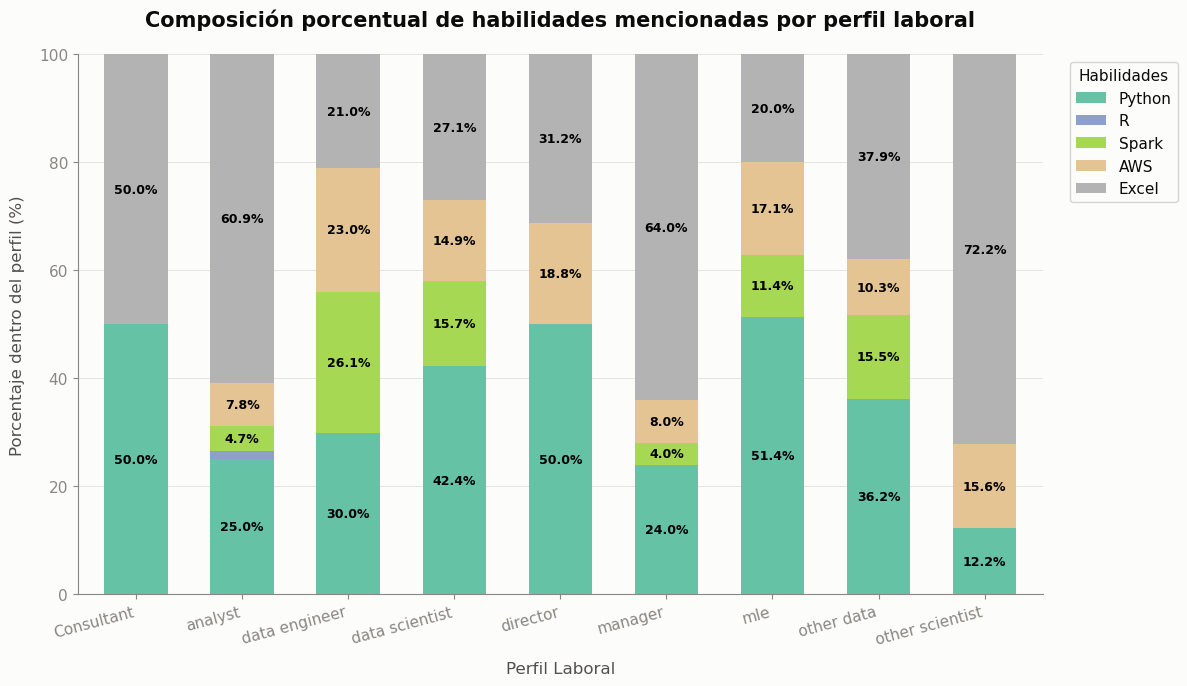

In [50]:
# 1. Agrupar por perfil y calcular la frecuencia promedio
habilidades = ["python_yn", "R_yn", "spark", "aws", "excel"]
df_grouped = df.groupby("job_simp")[habilidades].mean()

# 2. Convertir a porcentajes relativos (Normalizar para que cada fila sume 100%)
# Dividimos cada celda por la suma de su fila y multiplicamos por 100
df_percentage = df_grouped.div(df_grouped.sum(axis=1), axis=0) * 100

# 3. Renombrar las columnas para que la leyenda se vea limpia
df_percentage.columns = ["Python", "R", "Spark", "AWS", "Excel"]

# 4. Crear el gráfico utilizando pandas y matplotlib
ax = df_percentage.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7),
    colormap="Set2",  # Paleta de colores atractiva
    width=0.6,  # Grosor de las barras
)

# 5. Personalizar el diseño y estilo
plt.title(
    "Composición porcentual de habilidades mencionadas por perfil laboral",
    fontsize=15,
    weight="bold",
    pad=20,
)
plt.xlabel("Perfil Laboral", fontsize=12, labelpad=10)
plt.ylabel("Porcentaje dentro del perfil (%)", fontsize=12, labelpad=10)

# Asegurar que el eje Y vaya exactamente de 0 a 100
plt.ylim(0, 100)
plt.xticks(rotation=15, ha="right")

# Mover la leyenda fuera del gráfico
plt.legend(title="Habilidades", bbox_to_anchor=(1.02, 1), loc="upper left")

# 6. Opcional: Agregar etiquetas con el porcentaje dentro de cada segmento
for rect in ax.patches:
    width, height = rect.get_width(), rect.get_height()
    x, y = rect.get_xy()
    # Solo mostrar texto si el segmento es lo suficientemente grande
    if height > 4:
        ax.text(
            x + width / 2,
            y + height / 2,
            f"{height:.1f}%",
            ha="center",
            va="center",
            fontsize=9,
            color="black",
            weight="semibold",
        )

plt.tight_layout()
plt.show();

In [51]:
habilidades_en_ofertas=df[["python_yn","R_yn","spark","aws","excel"]].sum()/742 *100
habilidades_en_ofertas.sort_values(ascending=True)

R_yn          0.269542
spark        22.506739
aws          23.719677
excel        52.291105
python_yn    52.830189
dtype: float64

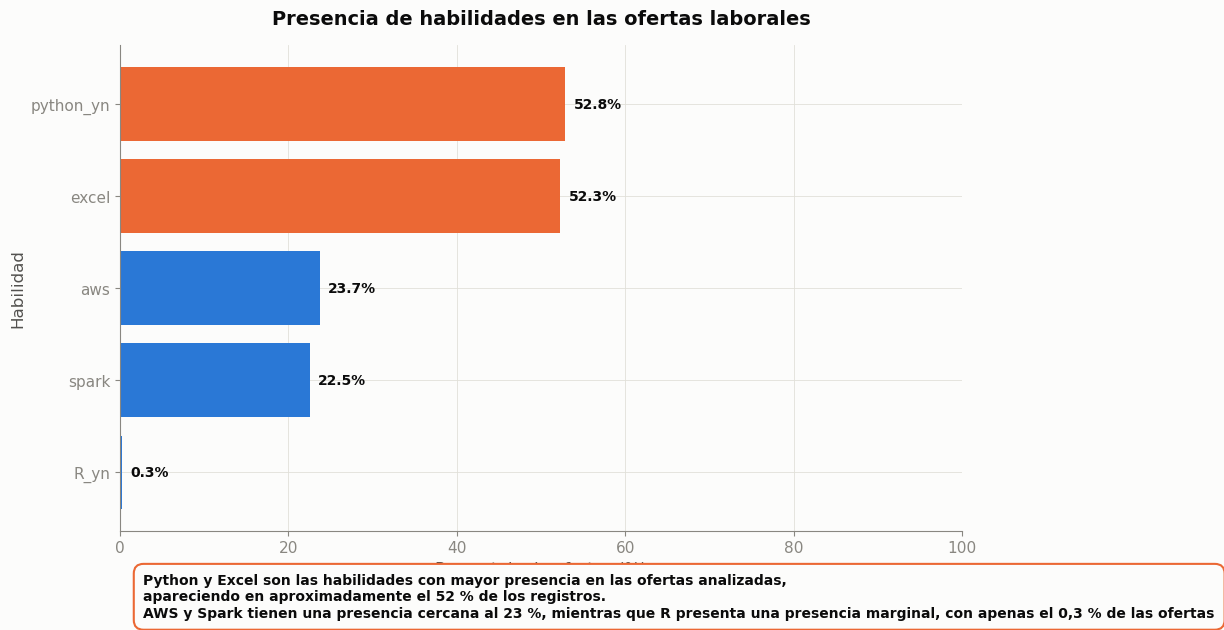

In [52]:
habilidades_en_ofertas= habilidades_en_ofertas.sort_values(ascending=True)
colores = [COLOR_PRIMARIO,COLOR_PRIMARIO, COLOR_PRIMARIO,COLOR_ACENTO, COLOR_ACENTO]

plt.figure(figsize=(10,6))
plt.barh(habilidades_en_ofertas.index, habilidades_en_ofertas.values, color=colores)

plt.title('Presencia de habilidades en las ofertas laborales', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Porcentaje de ofertas (%)', fontsize=12)
plt.ylabel('Habilidad', fontsize=12)
plt.xlim(0, 100) # Forzar el límite de 0% a 100% para dar contexto real

for index, value in enumerate(habilidades_en_ofertas.values):
    plt.text(value + 1, index, f'{value:.1f}%', va='center', fontsize=10, fontweight='bold')

    insight_texto = (
    "Python y Excel son las habilidades con mayor presencia en las ofertas analizadas,\n" 
     "apareciendo en aproximadamente el 52 % de los registros.\n"
     "AWS y Spark tienen una presencia cercana al 23 %, mientras que R presenta una presencia marginal, con apenas el 0,3 % de las ofertas"
)

plt.figtext(
    0.15, -0.04, insight_texto, # Cambiamos -0.04 por 0.02 (coordenada positiva)
    fontsize=10, 
    fontweight='bold', 
    color=COLOR_TEXTO,
    bbox=dict(
        facecolor=COLOR_SUPERFICIE, 
        edgecolor=COLOR_ACENTO, 
        linewidth=1.5, 
        boxstyle='round,pad=0.7'
    )
)


plt.tight_layout() # Ahora sí funcionará bien porque el título pertenece al gráfico
plt.show();

In [ ]:
columnas_a_mantener= ["Job Title", "Salary Estimate","Job Description", "Rating",
"company_txt","Location","Size","Type of ownership","Industry","Sector","Revenue","hourly","employer_provided","min_salary",
"max_salary","avg_salary","job_state","same_state","age","python_yn","R_yn","spark","aws","excel","job_simp","seniority"]

df_filtrado = df[columnas_a_mantener]


ruta = 
df_filtrado.to_csv(ruta, index=False, encoding="utf-8-sig")



In [ ]:


# 1. Definimos las columnas que identifican cada oferta (claves de contexto)
columnas_contexto = ['job_simp', 'job_state', 'seniority', 'hourly']

# 2. Definimos las columnas de habilidades tecnológicas
columnas_habilidades = ['python_yn', 'R_yn', 'spark', 'aws', 'excel']

# 3. Aplicamos pd.melt para crear la tabla secundaria de habilidades
df_habilidades = pd.melt(
    df_filtrado,
    id_vars=columnas_contexto,
    value_vars=columnas_habilidades,
    var_name='Herramienta',
    value_name='Requerido'
)

# 4. Limpiamos los nombres de las herramientas para el reporte
reemplazos = {
    'python_yn': 'Python',
    'R_yn': 'R',
    'spark': 'Spark',
    'aws': 'AWS',
    'excel': 'Excel'
}
df_habilidades['Herramienta'] = df_habilidades['Herramienta'].replace(reemplazos)
# 5. Guardamos el archivo para cargarlo en Power BI
ruta = 
df_habilidades.to_csv(ruta, index=False, encoding="utf-8-sig")
print("¡Tabla de habilidades generada con éxito!")


¡Tabla de habilidades generada con éxito!
